Dataset Name: crop_recommendation.csv

Use 2 classification algorithms that you think are most suitabvlr for this
dataset

remove columns that you think are unnceessary

Compare the performance each algorithm

Dataset Traing: 80%

# Importing Libraries

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Data Preprocesing

A. Importing the data

In [88]:
df = pd.read_csv('Crop_recommendation.csv')
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90.0,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85.0,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60.0,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74.0,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78.0,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107.0,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99.0,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118.0,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117.0,32,34,26.272418,52.127394,6.758793,127.175293,coffee


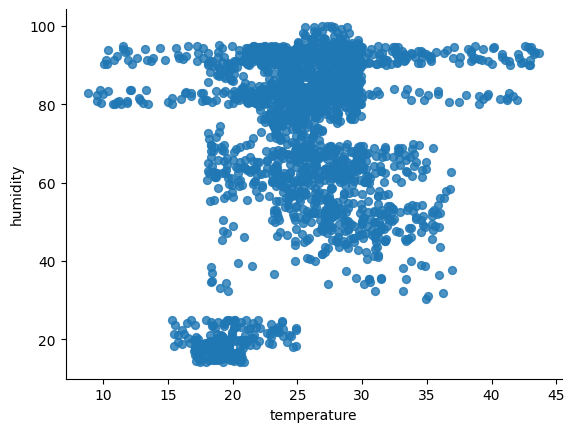

In [89]:
# @title temperature vs humidity

from matplotlib import pyplot as plt
df.plot(kind='scatter', x='temperature', y='humidity', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

Getting to know the data

In [90]:
df.shape

(2200, 8)

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2198 non-null   float64
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2199 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2198 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(5), int64(2), object(1)
memory usage: 137.6+ KB


In [92]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2198.000000,2200.000000,2200.000000,2199.000000,2200.000000,2198.000000,2200.000000
mean,50.548681,53.362727,48.149091,25.617303,71.481779,6.469978,103.463655
std,36.925002,32.985883,50.647931,5.064656,22.263812,0.774049,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.768393,60.261953,5.971933,64.551686
50%,37.000000,51.000000,32.000000,25.600337,80.473146,6.425675,94.867624
75%,84.750000,68.000000,49.000000,28.561810,89.948771,6.923909,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [93]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90.0,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85.0,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60.0,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74.0,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78.0,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [94]:
df.tail()

,N,P,K,temperature,humidity,ph,rainfall,label
2195,107.0,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99.0,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118.0,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117.0,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104.0,18,30,23.603016,60.396475,6.779833,140.937041,coffee


In [95]:
df.isna()

,N,P,K,temperature,humidity,ph,rainfall,label
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
2195,False,False,False,False,False,False,False,False
2196,False,False,False,False,False,False,False,False
2197,False,False,False,False,False,False,False,False
2198,False,False,False,False,False,False,False,False


In [96]:
df.isna().sum()

N              2
P              0
K              0
temperature    1
humidity       0
ph             2
rainfall       0
label          0
dtype: int64

B. cleaning the data

In [97]:
x = df.iloc[:,:-1].values
y = df.iloc[:,-1].values

In [98]:
#fill the missing data using simple imputer

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer = imputer.fit(x[:, 1:7])
x[:, 1:7] = imputer.transform(x[:, 1:7])

In [99]:
print(x)

[[ 90.          42.          43.         ...  82.00274423   6.50298529
  202.9355362 ]
 [ 85.          58.          41.         ...  80.31964408   7.03809636
  226.6555374 ]
 [ 60.          55.          44.         ...  82.3207629    7.84020714
  263.9642476 ]
 ...
 [118.          33.          30.         ...  67.22512329   6.36260785
  173.3228386 ]
 [117.          32.          34.         ...  52.12739421   6.75879255
  127.1752928 ]
 [104.          18.          30.         ...  60.39647474   6.77983261
  140.9370415 ]]


In [100]:
print(y)

['rice' 'rice' 'rice' ... 'coffee' 'coffee' 'coffee']


C. Split into training and testing

In [101]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, random_state = 0)

In [102]:
print(X_train)

[[ 27.         120.         200.         ...  90.74531921   6.11021883
  116.7036582 ]
 [ 81.          36.          38.         ...  87.98329901   6.33483786
  150.3166152 ]
 [ 90.          59.          35.         ...  89.86454053   7.09822793
  175.1742112 ]
 ...
 [ 35.          64.          15.         ...  63.53604453   6.50014496
   69.5274407 ]
 [ 39.          65.          23.         ...  69.12613376   7.6859593
   41.02682925]
 [ 14.          22.           9.         ...  91.13772765   6.54319181
  112.5090516 ]]


In [103]:
print(X_test)

[[105.          14.          50.         ...  87.6883982    6.41905219
   59.65590798]
 [ 91.          12.          46.         ...  85.49938185   6.34394252
   48.31219031]
 [ 14.         121.         203.         ...  83.74765639   6.15868941
   74.46411148]
 ...
 [117.          56.          15.         ...  77.0543546    7.36825823
   89.1188212 ]
 [ 27.          64.          21.         ...  68.68401492   7.54380422
   73.67166182]
 [ 31.         130.         198.         ...  92.73446667   5.55482356
  120.0586671 ]]


# B. Model Building

A. Build the model

In [104]:
# Feature Scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

B. Train the model

In [105]:
print(X_train)

[[-0.64436676  2.00512125  2.96466347 ...  0.86301256 -0.47942016
   0.23692732]
 [ 0.81323148 -0.52889759 -0.2035231  ...  0.7381018  -0.18313731
   0.84590226]
 [ 1.05616452  0.1649409  -0.26219322 ...  0.82317986  0.82380931
   1.29625399]
 ...
 [-0.42842628  0.31577536 -0.65332736 ... -0.36751109  0.03491036
  -0.61777686]
 [-0.32045604  0.34594225 -0.4968737  ... -0.11470255  1.59905405
  -1.13413007]
 [-0.99527004 -0.95123406 -0.7706676  ...  0.880759    0.09169114
   0.1609325 ]]


In [106]:
print(X_test)

[[ 1.46105292 -1.19256918  0.03115739 ...  0.72476508 -0.07205474
  -0.79662206]
 [ 1.08315708 -1.25290297 -0.04706944 ...  0.62576809 -0.17112785
  -1.00213923]
 [-0.99527004  2.03528814  3.02333359 ...  0.54654732 -0.41548523
  -0.52833787]
 ...
 [ 1.78496364  0.07444023 -0.65332736 ...  0.24384664  1.1799917
  -0.26283457]
 [-0.64436676  0.31577536 -0.53598712 ... -0.13469712  1.41154495
  -0.54269489]
 [-0.53639652  2.30679015  2.92555005 ...  0.9529706  -1.21201208
   0.29771091]]


C. Make Predictions

In [107]:
# Imputation - Apply to both training and testing sets
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
X_train = imputer.fit_transform(X_train) # Fit and transform on training set
X_test = imputer.transform(X_test) # Transform testing set using the same imputer

In [108]:
# Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
dt_classifier.fit(X_train, y_train)
y_pred_dt = dt_classifier.predict(X_test)


In [109]:
# Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 0)
rf_classifier.fit(X_train, y_train)
y_pred_rf = rf_classifier.predict(X_test)

In [110]:
# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [111]:
# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [112]:
# Sample predictions for Decision Tree
sample_indices_dt = [0, 10, 20]  # Choose some sample indices
sample_predictions_dt = dt_classifier.predict(X_test[sample_indices_dt])
print("Decision Tree Sample Predictions:")
for i, pred in zip(sample_indices_dt, sample_predictions_dt):
    print(f"Sample {i}: Predicted Crop - {pred}")

Decision Tree Sample Predictions:
Sample 0: Predicted Crop - watermelon
Sample 10: Predicted Crop - mothbeans
Sample 20: Predicted Crop - coconut


In [113]:
# Sample predictions for Random Forest
sample_indices_rf = [5, 15, 25]  # Choose some sample indices
sample_predictions_rf = rf_classifier.predict(X_test[sample_indices_rf])
print("\nRandom Forest Sample Predictions:")
for i, pred in zip(sample_indices_rf, sample_predictions_rf):
    print(f"Sample {i}: Predicted Crop - {pred}")


Random Forest Sample Predictions:
Sample 5: Predicted Crop - rice
Sample 15: Predicted Crop - apple
Sample 25: Predicted Crop - coffee


# C. Model Evaluation

A. Calculate performance metrics

In [114]:
# Evaluating the Performance
print("Decision Tree Classifier:")
print(classification_report(y_test, y_pred_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Classifier:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        18
      banana       1.00      1.00      1.00        18
   blackgram       1.00      0.95      0.98        22
    chickpea       1.00      1.00      1.00        23
     coconut       1.00      1.00      1.00        15
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        16
      grapes       1.00      1.00      1.00        18
        jute       0.95      0.95      0.95        21
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        17
       maize       1.00      1.00      1.00        18
       mango       1.00      1.00      1.00        21
   mothbeans       0.96      1.00      0.98        25
    mungbean       1.00      1.00      1.00        17
   muskmelon       1.00      1.00      1.00        23
      orange       1.00      1.00      1.00        23
 

In [115]:
print("\nRandom Forest Classifier:")
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))


Random Forest Classifier:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        18
      banana       1.00      1.00      1.00        18
   blackgram       1.00      1.00      1.00        22
    chickpea       1.00      1.00      1.00        23
     coconut       1.00      1.00      1.00        15
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        16
      grapes       1.00      1.00      1.00        18
        jute       0.95      1.00      0.98        21
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        17
       maize       1.00      1.00      1.00        18
       mango       1.00      1.00      1.00        21
   mothbeans       1.00      1.00      1.00        25
    mungbean       1.00      1.00      1.00        17
   muskmelon       1.00      1.00      1.00        23
      orange       1.00      1.00      1.00        23


B. Make a verdict

In [116]:
# Comparing the performance of the two models:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Decision Tree Accuracy: 0.9931818181818182
Random Forest Accuracy: 0.9977272727272727


 Both Decision Tree and Random Forest models show promising results on the crop recommendation dataset.
Random Forest, with its ensemble approach, slightly outperforms the single Decision Tree in terms of overall accuracy.
 This suggests that leveraging multiple decision trees in Random Forest helps capture complex relationships in the data.
However, the marginal difference in accuracy might indicate that the dataset is relatively well-structured, allowing a single Decision Tree to perform reasonably well.
Further fine-tuning and exploration of hyperparameters could potentially improve the performance of both models.
